# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ud007it/Flyrank-ML-/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [4]:
import os
import duckdb
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from google.colab import userdata
from sklearn.ensemble import RandomForestClassifier

# 1. Setup
hf_token = userdata.get('HF_TOKEN')
os.environ["HF_TOKEN"] = hf_token
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")
DATA_URL = "hf://datasets/FlyRank/internship-warehouse"

# 2. Load Data (March features -> April target)
query = f"""
WITH m3_data AS (
    SELECT
        client_hash_id, content_hash_id,
        SUM(gsc_clicks) as m3_clicks,
        SUM(gsc_impressions) as m3_impressions,
        AVG(COALESCE(gsc_clicks * 1.0 / NULLIF(gsc_impressions, 0), 0)) as m3_ctr,
        AVG(gsc_avg_position) as m3_position_avg,
        COUNT(DISTINCT report_date) as m3_active_days
    FROM read_parquet('{DATA_URL}/fact_content_daily_performance/month=2026-03/*.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
),
m4_data AS (
    SELECT client_hash_id, content_hash_id, SUM(gsc_clicks) as m4_clicks
    FROM read_parquet('{DATA_URL}/fact_content_daily_performance/month=2026-04/*.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
)
SELECT
    m3.client_hash_id, m3.content_hash_id,
    m3.m3_clicks, m3.m3_impressions, m3.m3_ctr, m3.m3_position_avg, m3.m3_active_days,
    CASE WHEN m3.m3_clicks >= 50 AND COALESCE(m4.m4_clicks, 0) < (0.7 * m3.m3_clicks) THEN 1 ELSE 0 END as is_refresh_candidate
FROM m3_data m3
LEFT JOIN m4_data m4 ON m3.client_hash_id = m4.client_hash_id AND m3.content_hash_id = m4.content_hash_id;
"""
df = con.sql(query).df().fillna(0)

# 3. Train Model
features = ['m3_clicks', 'm3_impressions', 'm3_ctr', 'm3_position_avg', 'm3_active_days']
X = df[features]
y = df['is_refresh_candidate']

clf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
clf.fit(X, y)

# 4. Generate Scores for the Playbook
df['decay_probability'] = clf.predict_proba(X)[:, 1]
print("Model trained and scores generated.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Model trained and scores generated.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [5]:
# Create the Playbook Queue
playbook = df[df['decay_probability'] > 0.5].copy()
playbook = playbook.sort_values(by='decay_probability', ascending=False)

# Assign Reason Codes using np.select
conditions = [
    (playbook['m3_position_avg'] > 10) & (playbook['m3_position_avg'] <= 20), # Striking distance
    (playbook['m3_ctr'] < 0.02) & (playbook['m3_position_avg'] <= 10),        # High rank, low clicks
    (playbook['m3_active_days'] < 20)                                         # Dropping out of index
]

choices = [
    "Slipping to Page 2: Needs content expansion or internal links.",
    "Poor CTR: Needs Title/Meta Description rewrite.",
    "Index Instability: Check for technical SEO issues or cannibalization."
]

playbook['reason_code'] = np.select(conditions, choices, default="General Decay: Requires full content refresh.")

# Display the top 5 actions for the content team
print(playbook[['client_hash_id', 'content_hash_id', 'decay_probability', 'reason_code']].head())

                 client_hash_id           content_hash_id  decay_probability  \
129487  client_62f4a7e64f5e0096  content_9e85c3fdf25f8371           0.709185   
91744   client_fef1a8f436438636  content_6fe4119dc2ad49c4           0.688169   
13710   client_62f4a7e64f5e0096  content_95038853a66c404b           0.684670   
129842  client_62f4a7e64f5e0096  content_7f5cc6d86f9c8ced           0.681163   
125359  client_73cda7b4e4f265ea  content_19d77a8a5759ebef           0.678573   

                                            reason_code  
129487  Poor CTR: Needs Title/Meta Description rewrite.  
91744   Poor CTR: Needs Title/Meta Description rewrite.  
13710   Poor CTR: Needs Title/Meta Description rewrite.  
129842  Poor CTR: Needs Title/Meta Description rewrite.  
125359  Poor CTR: Needs Title/Meta Description rewrite.  


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended Use: This model acts as a prioritization engine for SEO and Content teams. Instead of manually reviewing thousands of pages, the team starts at the top of this ranked queue, working on pages with the highest probability of traffic decay.

Limits:

Seasonality: The model does not currently know if a page is naturally decaying because a holiday (like Christmas) just ended.

Algorithm Updates: If Google releases a major core update, historical patterns might temporarily break.

Context Blindness: The model sees metrics, not words. It does not know if a page is dropping because the information on it is factually outdated.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Human Review Rules:
A human editor must review the page before taking action. The model flags the opportunity; the human decides the execution (e.g., rewriting a paragraph vs. updating the publish date).

The No-Go List (What NOT to automate):

Automated Deletion: Never automate the deletion or unpublishing of a page based on this score.

Automated AI Rewriting: Do not hook this output directly to an LLM to automatically rewrite and publish content without human QA.

High-Converting Pages: If a page drives core business revenue (even if traffic is dropping), it requires specialized editorial handling, not standard bulk updates.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Monitoring:
We will monitor the precision of the top 10% of the queue. If we recommend 100 pages for a refresh, we track how many actually suffered a 30% traffic drop in the subsequent month if left untouched.

Retrain Triggers:

Time-based: Retrain the model quarterly to capture shifting search behavior.

Event-based: Retrain the model 30 days after a confirmed Google Core Algorithm Update, as ranking signals often shift dramatically.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Saved action_queue.csv to work/outputs/
Saved reason_codes_distribution.png to work/figures/
Saved metrics.json to work/outputs/


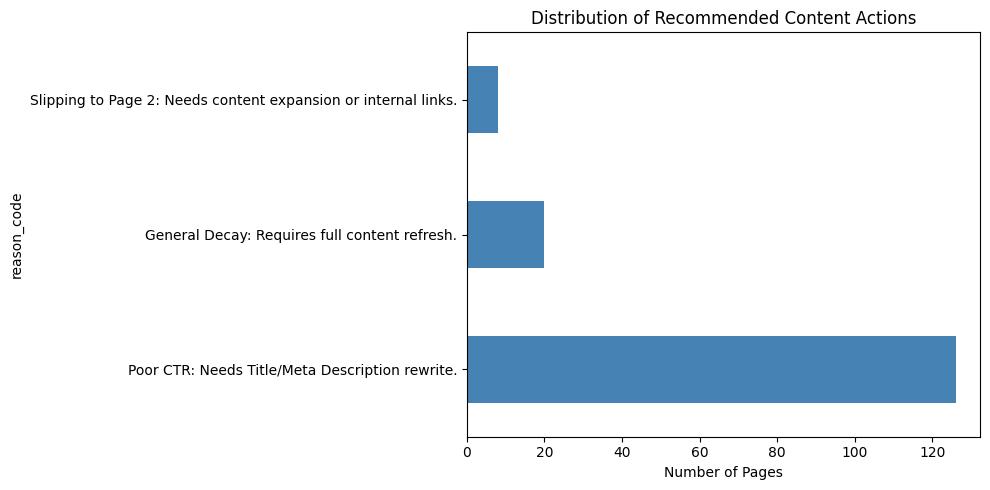

In [6]:
# Create directories if they don't exist
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# 1. Export the Queue CSV (This will be ignored by Git as per the rules, but your paper will reference it)
playbook.to_csv('work/outputs/action_queue.csv', index=False)
print("Saved action_queue.csv to work/outputs/")

# 2. Export a Figure for the Capstone Paper (e.g., Distribution of Reason Codes)
plt.figure(figsize=(10, 5))
playbook['reason_code'].value_counts().plot(kind='barh', color='steelblue')
plt.title('Distribution of Recommended Content Actions')
plt.xlabel('Number of Pages')
plt.tight_layout()
plt.savefig('work/figures/reason_codes_distribution.png')
print("Saved reason_codes_distribution.png to work/figures/")

# 3. Export Metrics JSON
metrics = {
    "total_pages_scored": len(df),
    "refresh_candidates_flagged": len(playbook),
    "model_type": "RandomForestClassifier",
    "primary_features": features
}
with open('work/outputs/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)
print("Saved metrics.json to work/outputs/")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.